# Pgen model: run and analyze

This notebook analyzes a trained sequence-to-`log10(pgen_1mm)` model.

It covers:
- loading the saved model and metadata
- reproducing the train/val/test split
- comparing predicted vs real `log10(pgen_1mm)`
- inspecting residuals and worst examples
- benchmarking inference time for several batch sizes

## 1. Define inputs

In [1]:
from pathlib import Path

root = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()

# Example TRB paths; update these for the chain/run you want to inspect.
airr_path = Path('/projects/immunestatus/vdjrearm/pgen_1mm_background_100k/trb_background_100k_pgen.tsv')
model_dir = Path('/projects/immunestatus/vdjrearm/irrmcodec/pgen_background_100k/trb')

airr_path, model_dir

(PosixPath('/projects/immunestatus/vdjrearm/pgen_1mm_background_100k/trb_background_100k_pgen.tsv'),
 PosixPath('/projects/immunestatus/vdjrearm/irrmcodec/pgen_background_100k/trb'))

In [2]:
import sys
sys.path.insert(0, str(root))

## 2. Imports

In [3]:
import json
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from torch.utils.data import DataLoader

from irrm_codec.dataio import normalize_locus_name, read_airr_table
from irrm_codec.datasets import PgenDataset, collate_pgen
from irrm_codec.pgen_model import PgenModel
from irrm_codec.tokenization import strip_gaps
from irrm_codec.utils import split_indices

sns.set_theme(context='notebook', style='whitegrid')

## 3. Load saved metadata

In [4]:
data_stats = json.loads((model_dir / 'data_stats.json').read_text())
history = json.loads((model_dir / 'history.json').read_text())
test_metrics = json.loads((model_dir / 'test_metrics.json').read_text())

data_stats, test_metrics

({'num_samples': 100000,
  'embedding_dim': 1,
  'num_unique_clone_ids': 100000,
  'min_length': 7,
  'max_length': 33,
  'mean_length': 15.13081,
  'processed_min_length': 40,
  'processed_max_length': 40,
  'processed_mean_length': 40.0,
  'truncated_fraction': 0.0,
  'unk_sequence_fraction': 0.0,
  'max_len': 40,
  'target_name': 'log10_pgen_1mm',
  'target_min': -31.885662078857422,
  'target_max': -3.9677212238311768,
  'target_mean': -8.31408977508545,
  'target_std': 2.5020182132720947,
  'airr_rows': 100000,
  'airr_rows_before_locus': 100000,
  'clone_id_column': 'clone_id',
  'target_column': 'log10_pgen_1mm',
  'locus': 'beta',
  'airr_path': '/projects/immunestatus/vdjrearm/pgen_1mm_background_100k/trb_background_100k_pgen.tsv',
  'seed': 42,
  'train_fraction': 0.8,
  'val_fraction': 0.1,
  'train_size': 80000,
  'val_size': 10000,
  'test_size': 10000,
  'checkpoints': {'best': 'best.pt', 'last': 'last.pt'}},
 {'loss': 0.13420600015670062,
  'mse': 0.3519491910934448,
  '

## 4. Rebuild the test split

In [5]:
target_col = data_stats.get('target_column', 'log10_pgen_1mm')
clone_id_col = data_stats.get('clone_id_column', 'clone_id')
locus = data_stats.get('locus')
seed = int(data_stats.get('seed', 42))
train_fraction = float(data_stats.get('train_fraction', 0.8))
val_fraction = float(data_stats.get('val_fraction', 0.1))
max_len = int(data_stats.get('max_len', 40))

df = read_airr_table(airr_path, clone_id_col=clone_id_col)
if locus is not None:
    locus_norm = normalize_locus_name(locus)
    locus_series = df['locus'].astype(str).str.strip().str.lower().map(normalize_locus_name)
    df = df.loc[locus_series == locus_norm].reset_index(drop=True)

target_array = pd.to_numeric(df[target_col], errors='coerce').to_numpy(dtype=np.float32)
train_idx, val_idx, test_idx = split_indices(
    len(df),
    train_fraction=train_fraction,
    val_fraction=val_fraction,
    seed=seed,
)

test_df = df.iloc[test_idx].reset_index(drop=True).copy()
test_target = target_array[test_idx]
test_df['target_log10_pgen_1mm'] = test_target

len(df), len(test_df)

(100000, 10000)

## 5. Load the trained model

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
checkpoint = torch.load(model_dir / 'best.pt', map_location=device)
extra = checkpoint.get('extra', {})

model = PgenModel(
    max_len=int(extra.get('max_len', max_len)),
    hidden_dim=int(extra.get('hidden_dim', 192)),
    mlp_dim=int(extra.get('mlp_dim', 512)),
    mlp_hidden_dim=int(extra.get('mlp_hidden_dim', 1024)),
    dropout=float(extra.get('dropout', 0.2)),
    dilations=tuple(int(part.strip()) for part in str(extra.get('dilations', '1,2,4,8')).split(',') if part.strip()),
    encoder_type=extra.get('encoder_type', 'plain_conv'),
).to(device)
model.load_state_dict(checkpoint['model_state'])
model.eval()

device, extra

/scratch/ipykernel_3314910/3577131615.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_dir / 'best.pt', map_location=device)


(device(type='cpu'),
 {'task': 'pgen_regression',
  'max_len': 40,
  'target_col': 'log10_pgen_1mm',
  'encoder_type': 'plain_conv',
  'hidden_dim': 192,
  'mlp_dim': 512,
  'mlp_hidden_dim': 1024,
  'dropout': 0.2,
  'dilations': '1,2,4,8'})

## 6. Predict on the test split

In [7]:
eval_batch_size = 1024
test_loader = DataLoader(
    PgenDataset(test_df, test_target, max_len=max_len),
    batch_size=eval_batch_size,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_pgen,
)

pred_batches = []
with torch.no_grad():
    for tokens, mask, target, _lengths in test_loader:
        tokens = tokens.to(device)
        mask = mask.to(device)
        pred = model(tokens, mask).detach().cpu().numpy()
        pred_batches.append(pred)

test_df['pred_log10_pgen_1mm'] = np.concatenate(pred_batches)
test_df['residual'] = test_df['pred_log10_pgen_1mm'] - test_df['target_log10_pgen_1mm']
test_df['abs_error'] = test_df['residual'].abs()
test_df['seq_length'] = test_df['junction_aa'].astype(str).map(lambda x: len(strip_gaps(x.replace('-', '').upper())))

test_df.head()

,junction_aa,v_call,j_call,locus,log10_pgen,log10_pgen_1mm,pgen,pgen_1mm,target_log10_pgen_1mm,pred_log10_pgen_1mm,residual,abs_error,seq_length
0,CASSLPRGQEQYF,TRBV7-9,TRBJ2-3,beta,-7.935702,-5.677865,1.159573e-08,2.099593e-06,-5.677865,-5.500239,0.177626,0.177626,13
1,CASSYGRLREAFF,TRBV5-6,TRBJ1-1,beta,-9.156649,-7.037188,6.971899e-10,9.179347e-08,-7.037188,-6.538300,0.498888,0.498888,13
2,CATSLVVGQASYNSPLHF,TRBV15,TRBJ1-6,beta,-12.805453,-9.872967,1.565117e-13,1.339778e-10,-9.872968,-8.289721,1.583247,1.583247,18
3,CASSWPSGKGSKNIQYF,TRBV3-1,TRBJ2-4,beta,-11.346867,-9.153489,4.499173e-12,7.022813e-10,-9.153489,-8.441799,0.711690,0.711690,17
4,CASSEVAGDSTDTQYF,TRBV10-1,TRBJ2-3,beta,-8.853166,-7.013159,1.402279e-09,9.701552e-08,-7.013159,-6.427657,0.585502,0.585502,16


## 7. Summary metrics

In [8]:
y_true = test_df['target_log10_pgen_1mm'].to_numpy(dtype=np.float64)
y_pred = test_df['pred_log10_pgen_1mm'].to_numpy(dtype=np.float64)
residual = y_pred - y_true

rmse = float(np.sqrt(np.mean((y_pred - y_true) ** 2)))
mae = float(np.mean(np.abs(y_pred - y_true)))
bias = float(np.mean(residual))
pearson = float(np.corrcoef(y_true, y_pred)[0, 1]) if len(y_true) > 1 else float('nan')
spearman = float(
    np.corrcoef(
        pd.Series(y_true).rank(method='average').to_numpy(),
        pd.Series(y_pred).rank(method='average').to_numpy(),
    )[0, 1]
) if len(y_true) > 1 else float('nan')
ss_res = float(np.sum((y_true - y_pred) ** 2))
ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float('nan')

summary = pd.DataFrame([
    {
        'rmse': rmse,
        'mae': mae,
        'bias': bias,
        'pearson': pearson,
        'spearman': spearman,
        'r2': r2,
        'n_test': len(test_df),
    }
])
summary

,rmse,mae,bias,pearson,spearman,r2,n_test
0,0.591382,0.473115,0.439949,0.987376,0.986116,0.943675,10000


## 8. Error plots

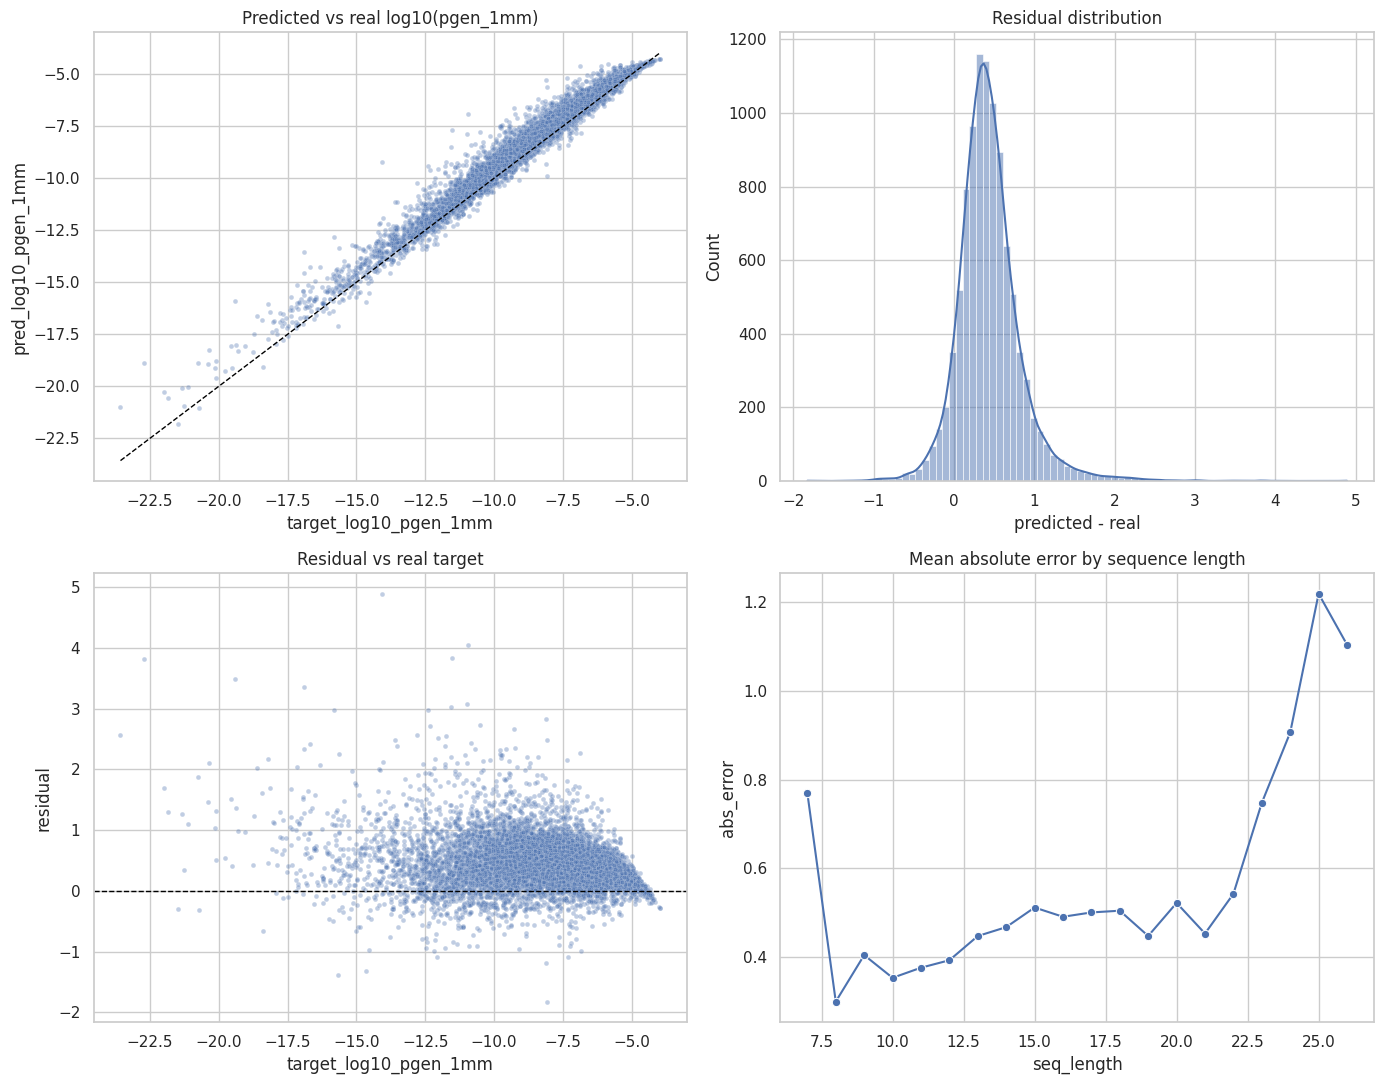

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

sns.scatterplot(
    data=test_df.sample(min(len(test_df), 20000), random_state=42),
    x='target_log10_pgen_1mm',
    y='pred_log10_pgen_1mm',
    s=12,
    alpha=0.35,
    ax=axes[0, 0],
)
xy_min = min(test_df['target_log10_pgen_1mm'].min(), test_df['pred_log10_pgen_1mm'].min())
xy_max = max(test_df['target_log10_pgen_1mm'].max(), test_df['pred_log10_pgen_1mm'].max())
axes[0, 0].plot([xy_min, xy_max], [xy_min, xy_max], '--', color='black', linewidth=1)
axes[0, 0].set_title('Predicted vs real log10(pgen_1mm)')

sns.histplot(test_df['residual'], bins=80, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Residual distribution')
axes[0, 1].set_xlabel('predicted - real')

sns.scatterplot(
    data=test_df.sample(min(len(test_df), 20000), random_state=42),
    x='target_log10_pgen_1mm',
    y='residual',
    s=12,
    alpha=0.35,
    ax=axes[1, 0],
)
axes[1, 0].axhline(0.0, linestyle='--', color='black', linewidth=1)
axes[1, 0].set_title('Residual vs real target')

length_error = test_df.groupby('seq_length', as_index=False)['abs_error'].mean()
sns.lineplot(data=length_error, x='seq_length', y='abs_error', marker='o', ax=axes[1, 1])
axes[1, 1].set_title('Mean absolute error by sequence length')

plt.tight_layout()

## 9. Largest errors

In [11]:
test_df

,junction_aa,v_call,j_call,locus,log10_pgen,log10_pgen_1mm,pgen,pgen_1mm,target_log10_pgen_1mm,pred_log10_pgen_1mm,residual,abs_error,seq_length
0,CASSLPRGQEQYF,TRBV7-9,TRBJ2-3,beta,-7.935702,-5.677865,1.159573e-08,2.099593e-06,-5.677865,-5.500239,0.177626,0.177626,13
1,CASSYGRLREAFF,TRBV5-6,TRBJ1-1,beta,-9.156649,-7.037188,6.971899e-10,9.179347e-08,-7.037188,-6.538300,0.498888,0.498888,13
2,CATSLVVGQASYNSPLHF,TRBV15,TRBJ1-6,beta,-12.805453,-9.872967,1.565117e-13,1.339778e-10,-9.872968,-8.289721,1.583247,1.583247,18
3,CASSWPSGKGSKNIQYF,TRBV3-1,TRBJ2-4,beta,-11.346867,-9.153489,4.499173e-12,7.022813e-10,-9.153489,-8.441799,0.711690,0.711690,17
4,CASSEVAGDSTDTQYF,TRBV10-1,TRBJ2-3,beta,-8.853166,-7.013159,1.402279e-09,9.701552e-08,-7.013159,-6.427657,0.585502,0.585502,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,CARGVEKLFF,TRBV10-1,TRBJ1-4,beta,-7.048455,-5.572784,8.944275e-08,2.674333e-06,-5.572784,-5.714495,-0.141710,0.141710,10
9996,CASSQGPDRYNQPQHF,TRBV4-1,TRBJ1-5,beta,-9.409616,-7.321642,3.893891e-10,4.768240e-08,-7.321642,-7.058802,0.262840,0.262840,16
9997,CASRIEVNGANVLTF,TRBV12-4,TRBJ2-6,beta,-10.885289,-8.523100,1.302301e-11,2.998474e-09,-8.523100,-8.010832,0.512268,0.512268,15
9998,CATSDLRGHEQFF,TRBV24-1,TRBJ2-1,beta,-7.895555,-6.429706,1.271876e-08,3.717868e-07,-6.429706,-6.412624,0.017082,0.017082,13


In [12]:
worst = test_df.sort_values('abs_error', ascending=False).head(20)
worst[['junction_aa', 'locus', 'target_log10_pgen_1mm', 'pred_log10_pgen_1mm', 'residual', 'abs_error']]

,junction_aa,locus,target_log10_pgen_1mm,pred_log10_pgen_1mm,residual,abs_error
6734,CASERQTIEYGLFF,beta,-14.086957,-9.196977,4.889980,4.889980
9020,CASSGGHTPNDF,beta,-10.943146,-6.894642,4.048503,4.048503
3446,CASSRMSGPGSPYTF,beta,-11.545276,-7.705328,3.839948,3.839948
6392,CASSFRNPQAEHRTTGQSTLFF,beta,-22.702007,-18.879013,3.822994,3.822994
2958,CSARAKRMMSSGGGTWVF,beta,-19.413784,-15.922945,3.490839,3.490839
3501,CATWGGSCGGFRPYEAFF,beta,-16.899652,-13.541199,3.358454,3.358454
2588,CASSYRGLHGDSF,beta,-10.971813,-7.894876,3.076937,3.076937
8131,CATSASSGAGNEYF,beta,-11.547570,-8.517545,3.030025,3.030025
4493,CSVGRPDNAGTSGTELFF,beta,-15.815248,-12.844262,2.970986,2.970986
583,CASKVSTSGARTLFF,beta,-12.393200,-9.423871,2.969329,2.969329


## 10. Inference speed benchmark

In [13]:
def benchmark_inference(model, df, device, max_len, batch_sizes=(1, 16, 64, 256, 1024), num_repeats=5):
    records = []
    for batch_size in batch_sizes:
        loader = DataLoader(
            PgenDataset(df, np.zeros(len(df), dtype=np.float32), max_len=max_len),
            batch_size=batch_size,
            shuffle=False,
            num_workers=0,
            collate_fn=collate_pgen,
        )

        with torch.no_grad():
            for tokens, mask, _target, _lengths in loader:
                tokens = tokens.to(device)
                mask = mask.to(device)
                _ = model(tokens, mask)
                break
            if device.type == 'cuda':
                torch.cuda.synchronize()

        elapsed = []
        for _ in range(num_repeats):
            start = time.perf_counter()
            with torch.no_grad():
                for tokens, mask, _target, _lengths in loader:
                    tokens = tokens.to(device)
                    mask = mask.to(device)
                    _ = model(tokens, mask)
                if device.type == 'cuda':
                    torch.cuda.synchronize()
            elapsed.append(time.perf_counter() - start)

        mean_seconds = float(np.mean(elapsed))
        records.append(
            {
                'batch_size': batch_size,
                'num_sequences': int(len(df)),
                'mean_seconds': mean_seconds,
                'std_seconds': float(np.std(elapsed)),
                'seq_per_second': float(len(df) / mean_seconds),
                'ms_per_sequence': float(mean_seconds * 1000.0 / len(df)),
            }
        )
    return pd.DataFrame(records)


benchmark_df = benchmark_inference(
    model=model,
    df=test_df[['junction_aa']].assign(locus=test_df['locus']).assign(v_call=test_df['v_call']).assign(j_call=test_df['j_call']),
    device=device,
    max_len=max_len,
    batch_sizes=(1, 16, 64, 256, 1024),
    num_repeats=5,
)
benchmark_df

,batch_size,num_sequences,mean_seconds,std_seconds,seq_per_second,ms_per_sequence
0,1,10000,30.859676,0.180641,324.047476,3.085968
1,16,10000,2.026693,0.004268,4934.146372,0.202669
2,64,10000,1.030353,0.003711,9705.414820,0.103035
3,256,10000,0.908940,0.121687,11001.831596,0.090894
4,1024,10000,1.083369,0.077473,9230.464051,0.108337


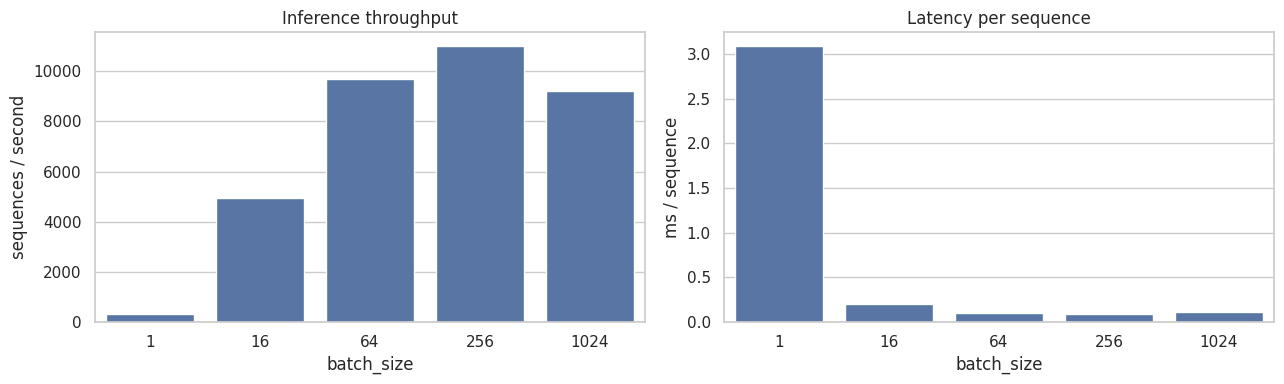

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.barplot(data=benchmark_df, x='batch_size', y='seq_per_second', ax=axes[0])
axes[0].set_title('Inference throughput')
axes[0].set_ylabel('sequences / second')

sns.barplot(data=benchmark_df, x='batch_size', y='ms_per_sequence', ax=axes[1])
axes[1].set_title('Latency per sequence')
axes[1].set_ylabel('ms / sequence')

plt.tight_layout()